In [1]:
# 1. LOADING LIBRARIES

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [3]:
# 2. LOADING THE DATASET FROM A CSV FILE

In [4]:
df = pd.read_csv("mpesa_fraud_detection_dataset.csv")

In [5]:
# 3. EXPLORATORY DATA ANALYSIS

In [6]:
# Displaying the first 10 records

In [7]:
df.head(10)

,TransactionID,Amount,SenderCounty,ReceiverCounty,TimeOfDay,TransactionType,AccountAgeMonths,TransactionsLast24Hours,DeviceChangedRecently,NewLocationLogin,FailedPinAttempts,IsWeekend,Fraudulent
0,TXN000001,335293,Mombasa,Nyeri,2,Withdraw,15,1,No,Yes,3,Yes,Yes
1,TXN000002,16713,Nyeri,Nakuru,22,Withdraw,4,3,Yes,Yes,8,Yes,Yes
2,TXN000003,115624,Machakos,Kiambu,4,Paybill,58,19,No,Yes,2,No,No
3,TXN000004,400340,Machakos,Meru,8,Send Money,44,4,Yes,No,1,No,No
4,TXN000005,382639,Meru,Machakos,18,Paybill,59,18,Yes,No,1,No,No
5,TXN000006,369448,Mombasa,Uasin Gishu,8,Withdraw,9,2,Yes,No,1,Yes,No
6,TXN000007,333331,Kiambu,Mombasa,19,Paybill,107,12,Yes,No,5,Yes,Yes
7,TXN000008,280093,Nyeri,Nakuru,21,Till,94,8,Yes,No,6,No,Yes
8,TXN000009,441947,Uasin Gishu,Kiambu,2,Paybill,99,25,Yes,Yes,0,No,Yes
9,TXN000010,478796,Kakamega,Kisumu,8,Paybill,73,29,No,Yes,7,No,Yes


In [8]:
# Displaying the last 10 records

In [9]:
df.tail(10)

,TransactionID,Amount,SenderCounty,ReceiverCounty,TimeOfDay,TransactionType,AccountAgeMonths,TransactionsLast24Hours,DeviceChangedRecently,NewLocationLogin,FailedPinAttempts,IsWeekend,Fraudulent
4990,TXN004991,406837,Meru,Nairobi,23,Paybill,15,3,Yes,No,0,Yes,No
4991,TXN004992,345183,Uasin Gishu,Nairobi,16,Withdraw,84,22,No,No,7,Yes,No
4992,TXN004993,119863,Uasin Gishu,Uasin Gishu,22,Withdraw,114,26,Yes,Yes,5,Yes,Yes
4993,TXN004994,337045,Nyeri,Nairobi,20,Send Money,64,14,Yes,No,5,Yes,Yes
4994,TXN004995,178181,Nairobi,Uasin Gishu,20,Paybill,107,30,Yes,Yes,8,Yes,Yes
4995,TXN004996,189164,Kiambu,Kiambu,2,Till,7,23,Yes,No,5,No,Yes
4996,TXN004997,406287,Mombasa,Uasin Gishu,1,Till,9,28,Yes,No,3,No,Yes
4997,TXN004998,6787,Meru,Mombasa,20,Send Money,90,6,Yes,No,6,Yes,No
4998,TXN004999,389058,Nyeri,Kiambu,19,Send Money,115,29,No,Yes,6,No,Yes
4999,TXN005000,124311,Meru,Mombasa,3,Withdraw,18,27,Yes,No,7,No,Yes


In [10]:
# Determining the number of rows and columns

In [11]:
df.shape

(5000, 13)

In [12]:
# the dataset has 5000 rows and 13 features

In [13]:
# listing all the features available for analysis

In [14]:
df.columns

Index(['TransactionID', 'Amount', 'SenderCounty', 'ReceiverCounty',
       'TimeOfDay', 'TransactionType', 'AccountAgeMonths',
       'TransactionsLast24Hours', 'DeviceChangedRecently', 'NewLocationLogin',
       'FailedPinAttempts', 'IsWeekend', 'Fraudulent'],
      dtype='object')

In [15]:
# # Data types and non‑null counts


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   TransactionID            5000 non-null   object
 1   Amount                   5000 non-null   int64 
 2   SenderCounty             5000 non-null   object
 3   ReceiverCounty           5000 non-null   object
 4   TimeOfDay                5000 non-null   int64 
 5   TransactionType          5000 non-null   object
 6   AccountAgeMonths         5000 non-null   int64 
 7   TransactionsLast24Hours  5000 non-null   int64 
 8   DeviceChangedRecently    5000 non-null   object
 9   NewLocationLogin         5000 non-null   object
 10  FailedPinAttempts        5000 non-null   int64 
 11  IsWeekend                5000 non-null   object
 12  Fraudulent               5000 non-null   object
dtypes: int64(5), object(8)
memory usage: 507.9+ KB


In [17]:
# statistical summary  for num columns


In [18]:
df.describe()

,Amount,TimeOfDay,AccountAgeMonths,TransactionsLast24Hours,FailedPinAttempts
count,5000.0000,5000.000000,5000.000000,5000.0000,5000.000000
mean,251214.9510,11.651000,60.631400,15.6116,3.965400
std,145598.8242,6.944382,34.911856,8.6213,2.575564
min,189.0000,0.000000,1.000000,1.0000,0.000000
25%,125706.2500,6.000000,31.000000,8.0000,2.000000
50%,251930.0000,12.000000,60.000000,15.0000,4.000000
75%,380742.7500,18.000000,91.000000,23.0000,6.000000
max,499956.0000,23.000000,120.000000,30.0000,8.000000


In [19]:
df.describe(include = "all")

,TransactionID,Amount,SenderCounty,ReceiverCounty,TimeOfDay,TransactionType,AccountAgeMonths,TransactionsLast24Hours,DeviceChangedRecently,NewLocationLogin,FailedPinAttempts,IsWeekend,Fraudulent
count,5000,5000.0000,5000,5000,5000.000000,5000,5000.000000,5000.0000,5000,5000,5000.000000,5000,5000
unique,5000,NaN,10,10,NaN,4,NaN,NaN,2,2,NaN,2,2
top,TXN000001,NaN,Uasin Gishu,Meru,NaN,Withdraw,NaN,NaN,No,No,NaN,No,Yes
freq,1,NaN,536,527,NaN,1297,NaN,NaN,2513,2515,NaN,2569,2754
mean,NaN,251214.9510,NaN,NaN,11.651000,NaN,60.631400,15.6116,NaN,NaN,3.965400,NaN,NaN
std,NaN,145598.8242,NaN,NaN,6.944382,NaN,34.911856,8.6213,NaN,NaN,2.575564,NaN,NaN
min,NaN,189.0000,NaN,NaN,0.000000,NaN,1.000000,1.0000,NaN,NaN,0.000000,NaN,NaN
25%,NaN,125706.2500,NaN,NaN,6.000000,NaN,31.000000,8.0000,NaN,NaN,2.000000,NaN,NaN
50%,NaN,251930.0000,NaN,NaN,12.000000,NaN,60.000000,15.0000,NaN,NaN,4.000000,NaN,NaN
75%,NaN,380742.7500,NaN,NaN,18.000000,NaN,91.000000,23.0000,NaN,NaN,6.000000,NaN,NaN


In [20]:
# identifying numerical columns

In [21]:
numerical_cols = df.select_dtypes(include = ["int64"])
numerical_cols

,Amount,TimeOfDay,AccountAgeMonths,TransactionsLast24Hours,FailedPinAttempts
0,335293,2,15,1,3
1,16713,22,4,3,8
2,115624,4,58,19,2
3,400340,8,44,4,1
4,382639,18,59,18,1
...,...,...,...,...,...
4995,189164,2,7,23,5
4996,406287,1,9,28,3
4997,6787,20,90,6,6
4998,389058,19,115,29,6


In [22]:
# identifying categorical columns

In [23]:
categorical_cols = df.select_dtypes(include = ["object"])
categorical_cols

,TransactionID,SenderCounty,ReceiverCounty,TransactionType,DeviceChangedRecently,NewLocationLogin,IsWeekend,Fraudulent
0,TXN000001,Mombasa,Nyeri,Withdraw,No,Yes,Yes,Yes
1,TXN000002,Nyeri,Nakuru,Withdraw,Yes,Yes,Yes,Yes
2,TXN000003,Machakos,Kiambu,Paybill,No,Yes,No,No
3,TXN000004,Machakos,Meru,Send Money,Yes,No,No,No
4,TXN000005,Meru,Machakos,Paybill,Yes,No,No,No
...,...,...,...,...,...,...,...,...
4995,TXN004996,Kiambu,Kiambu,Till,Yes,No,No,Yes
4996,TXN004997,Mombasa,Uasin Gishu,Till,Yes,No,No,Yes
4997,TXN004998,Meru,Mombasa,Send Money,Yes,No,Yes,No
4998,TXN004999,Nyeri,Kiambu,Send Money,No,Yes,No,Yes


In [24]:
# 4. DATA CLEANING

In [25]:
# check for missing values

In [26]:
missing_values = df.isnull().sum()
missing_values

TransactionID              0
Amount                     0
SenderCounty               0
ReceiverCounty             0
TimeOfDay                  0
TransactionType            0
AccountAgeMonths           0
TransactionsLast24Hours    0
DeviceChangedRecently      0
NewLocationLogin           0
FailedPinAttempts          0
IsWeekend                  0
Fraudulent                 0
dtype: int64

In [27]:
# there are no missing values in our dataframe

In [28]:
# check for duplicate values 

In [29]:
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

In [30]:
# there are no duplicate values in our dataframe

In [31]:
# check for outliers using IQR method

In [32]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

Amount: 0 outliers
TimeOfDay: 0 outliers
AccountAgeMonths: 0 outliers
TransactionsLast24Hours: 0 outliers
FailedPinAttempts: 0 outliers


In [33]:
# visualizing outliers using a boxplot

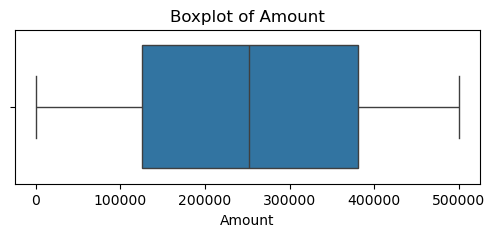

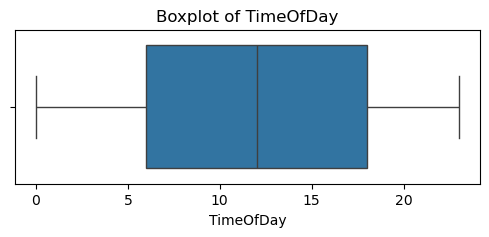

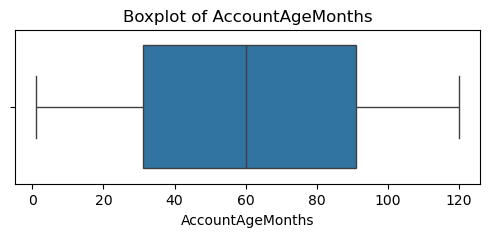

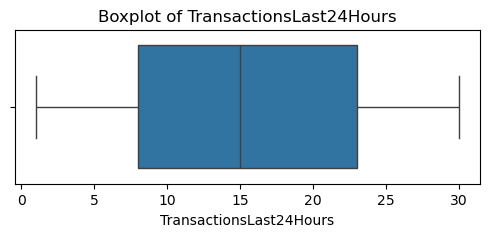

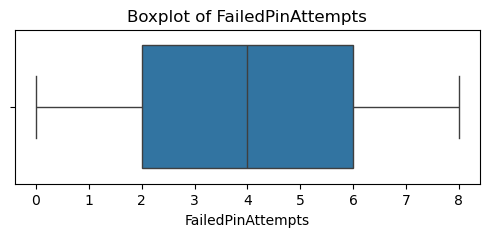

In [34]:
for col in numerical_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [35]:
# there are no outliers in our data

In [36]:
# 5. FRAUD ANALYSIS

In [37]:
# total transactions

In [38]:
total_transactions = len(df)
print(total_transactions)

5000


In [39]:
# fraudulent transactions

In [40]:
# check for unique entries in fradulent column

In [41]:
df["Fraudulent"].unique()

array(['Yes', 'No'], dtype=object)

In [42]:
fradulent_df = df[df["Fraudulent"] == "Yes"]
fradulent_df

,TransactionID,Amount,SenderCounty,ReceiverCounty,TimeOfDay,TransactionType,AccountAgeMonths,TransactionsLast24Hours,DeviceChangedRecently,NewLocationLogin,FailedPinAttempts,IsWeekend,Fraudulent
0,TXN000001,335293,Mombasa,Nyeri,2,Withdraw,15,1,No,Yes,3,Yes,Yes
1,TXN000002,16713,Nyeri,Nakuru,22,Withdraw,4,3,Yes,Yes,8,Yes,Yes
6,TXN000007,333331,Kiambu,Mombasa,19,Paybill,107,12,Yes,No,5,Yes,Yes
7,TXN000008,280093,Nyeri,Nakuru,21,Till,94,8,Yes,No,6,No,Yes
8,TXN000009,441947,Uasin Gishu,Kiambu,2,Paybill,99,25,Yes,Yes,0,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,TXN004995,178181,Nairobi,Uasin Gishu,20,Paybill,107,30,Yes,Yes,8,Yes,Yes
4995,TXN004996,189164,Kiambu,Kiambu,2,Till,7,23,Yes,No,5,No,Yes
4996,TXN004997,406287,Mombasa,Uasin Gishu,1,Till,9,28,Yes,No,3,No,Yes
4998,TXN004999,389058,Nyeri,Kiambu,19,Send Money,115,29,No,Yes,6,No,Yes


In [43]:
# total fradulent transactions

In [44]:
total_fradulent_transactions = len(fradulent_df)
print(total_fradulent_transactions)

2754


In [45]:
# fraud percentage 

In [46]:
fraud_percentage = (total_fradulent_transactions/total_transactions) * 100
print("Fraud percentage =", fraud_percentage)

Fraud percentage = 55.08


In [47]:
# saving the fradulent csv

In [48]:
# Summary statistics for the fradulent data frame

In [49]:
fradulent_df.head(10)

,TransactionID,Amount,SenderCounty,ReceiverCounty,TimeOfDay,TransactionType,AccountAgeMonths,TransactionsLast24Hours,DeviceChangedRecently,NewLocationLogin,FailedPinAttempts,IsWeekend,Fraudulent
0,TXN000001,335293,Mombasa,Nyeri,2,Withdraw,15,1,No,Yes,3,Yes,Yes
1,TXN000002,16713,Nyeri,Nakuru,22,Withdraw,4,3,Yes,Yes,8,Yes,Yes
6,TXN000007,333331,Kiambu,Mombasa,19,Paybill,107,12,Yes,No,5,Yes,Yes
7,TXN000008,280093,Nyeri,Nakuru,21,Till,94,8,Yes,No,6,No,Yes
8,TXN000009,441947,Uasin Gishu,Kiambu,2,Paybill,99,25,Yes,Yes,0,No,Yes
9,TXN000010,478796,Kakamega,Kisumu,8,Paybill,73,29,No,Yes,7,No,Yes
14,TXN000015,80181,Nairobi,Mombasa,11,Till,48,25,Yes,Yes,5,No,Yes
15,TXN000016,125591,Nyeri,Kisumu,4,Withdraw,8,8,Yes,Yes,7,Yes,Yes
17,TXN000018,229740,Mombasa,Machakos,0,Paybill,116,17,No,Yes,3,Yes,Yes
18,TXN000019,308562,Nairobi,Machakos,2,Paybill,29,1,Yes,Yes,3,Yes,Yes


In [50]:
fradulent_df.describe()

,Amount,TimeOfDay,AccountAgeMonths,TransactionsLast24Hours,FailedPinAttempts
count,2754.000000,2754.000000,2754.000000,2754.000000,2754.000000
mean,261294.371823,11.528322,59.672113,16.075163,4.851852
std,141942.024130,6.992973,35.256112,8.525968,2.219646
min,189.000000,0.000000,1.000000,1.000000,0.000000
25%,144050.750000,5.000000,29.000000,9.000000,3.000000
50%,265976.000000,12.000000,60.000000,16.000000,5.000000
75%,385979.000000,18.000000,91.000000,24.000000,7.000000
max,499956.000000,23.000000,120.000000,30.000000,8.000000


In [51]:
fradulent_df.groupby("SenderCounty")["Amount"].mean().sort_values(ascending=False)

SenderCounty
Kiambu         275040.043651
Nyeri          271236.995902
Kakamega       271096.779412
Mombasa        263455.034615
Uasin Gishu    259321.060606
Meru           258830.560886
Nairobi        257539.414545
Kisumu         254591.296774
Nakuru         254366.809701
Machakos       251795.954098
Name: Amount, dtype: float64

In [52]:
fradulent_df.groupby("SenderCounty").size().sort_values(ascending=False)

SenderCounty
Kisumu         310
Machakos       305
Uasin Gishu    297
Nairobi        275
Kakamega       272
Meru           271
Nakuru         268
Mombasa        260
Kiambu         252
Nyeri          244
dtype: int64

In [53]:
fradulent_df.groupby("ReceiverCounty")["Amount"].mean().sort_values(ascending=False)

ReceiverCounty
Nakuru         272847.829710
Machakos       267325.958801
Kisumu         266159.264925
Uasin Gishu    265695.332075
Nairobi        261192.480287
Nyeri          259211.812287
Kakamega       258239.204461
Kiambu         255772.413043
Mombasa        254005.671480
Meru           253316.394366
Name: Amount, dtype: float64

In [54]:
fradulent_df.groupby("ReceiverCounty").size().sort_values(ascending=False)

ReceiverCounty
Nyeri          293
Meru           284
Nairobi        279
Mombasa        277
Kiambu         276
Nakuru         276
Kakamega       269
Kisumu         268
Machakos       267
Uasin Gishu    265
dtype: int64

In [55]:
fradulent_df.groupby("TimeOfDay").size().sort_values(ascending=False)

TimeOfDay
13    132
0     131
20    128
3     125
17    125
22    124
4     124
8     124
14    120
23    118
15    116
18    115
2     114
10    111
11    110
6     109
5     107
19    106
1     105
16    105
21    105
12    102
9     101
7      97
dtype: int64

In [56]:
fradulent_df.groupby("TransactionType")["Amount"].mean().sort_values(ascending=False)

TransactionType
Paybill       266573.031746
Till          264746.586524
Send Money    260177.251412
Withdraw      253977.962857
Name: Amount, dtype: float64

In [57]:
fradulent_df.groupby("TransactionType").size().sort_values(ascending=False)

TransactionType
Send Money    708
Withdraw      700
Paybill       693
Till          653
dtype: int64

In [58]:
fradulent_df.groupby("AccountAgeMonths").size().sort_values(ascending=False)

AccountAgeMonths
1     44
2     39
36    34
75    34
39    31
      ..
25    15
81    15
74    15
69    13
23    12
Length: 120, dtype: int64

In [59]:
fradulent_df.groupby("DeviceChangedRecently")["Amount"].mean().sort_values(ascending=False)

DeviceChangedRecently
No     268904.093951
Yes    258303.600910
Name: Amount, dtype: float64

In [60]:
fradulent_df.groupby("DeviceChangedRecently").size().sort_values(ascending=False)

DeviceChangedRecently
Yes    1977
No      777
dtype: int64

In [61]:
fradulent_df.groupby("NewLocationLogin")["Amount"].mean().sort_values(ascending=False)

NewLocationLogin
No     262277.875472
Yes    260895.247065
Name: Amount, dtype: float64

In [62]:
fradulent_df.groupby("NewLocationLogin").size().sort_values(ascending=False)

NewLocationLogin
Yes    1959
No      795
dtype: int64

In [63]:
fradulent_df.groupby("IsWeekend")["Amount"].mean().sort_values(ascending=False)

IsWeekend
No     262787.692254
Yes    259704.780360
Name: Amount, dtype: float64

In [64]:
fradulent_df.groupby("IsWeekend").size().sort_values(ascending=False)

IsWeekend
No     1420
Yes    1334
dtype: int64

In [65]:
fradulent_df.groupby("FailedPinAttempts").size().sort_values(ascending=False)

FailedPinAttempts
7    426
4    417
3    407
5    401
6    372
8    362
0    132
2    121
1    116
dtype: int64

In [66]:
# transaction type distribution 

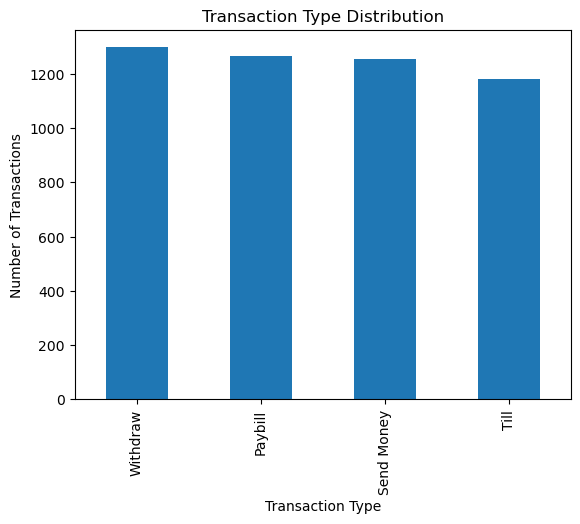

In [67]:
df["TransactionType"].value_counts().plot(kind="bar")

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

In [68]:
# fradulent transaction type distribution 

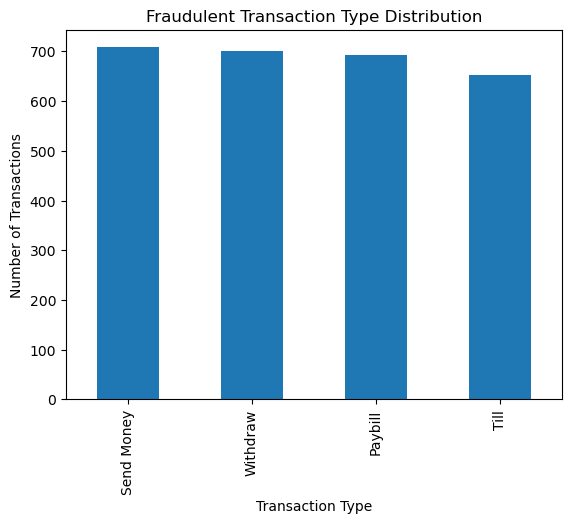

In [69]:
fradulent_df["TransactionType"].value_counts().plot(kind="bar")

plt.title("Fraudulent Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

In [70]:
# fraud by county

In [71]:
fradulent_df.groupby("SenderCounty").size().sort_values(ascending=False)

SenderCounty
Kisumu         310
Machakos       305
Uasin Gishu    297
Nairobi        275
Kakamega       272
Meru           271
Nakuru         268
Mombasa        260
Kiambu         252
Nyeri          244
dtype: int64

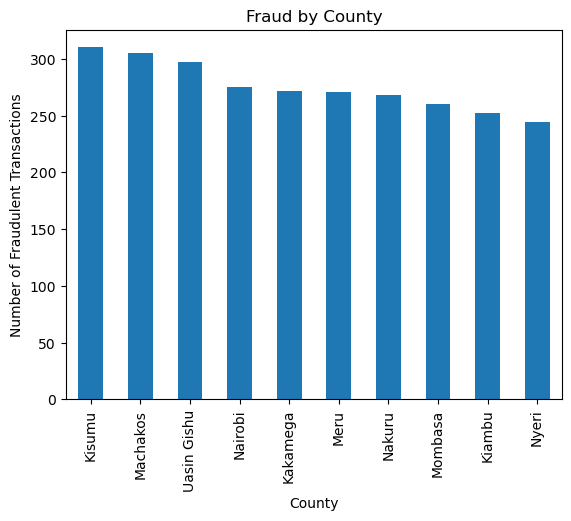

In [72]:
fradulent_df["SenderCounty"].value_counts().plot(kind="bar")

plt.title("Fraud by County")
plt.xlabel("County")
plt.ylabel("Number of Fraudulent Transactions")
plt.show()

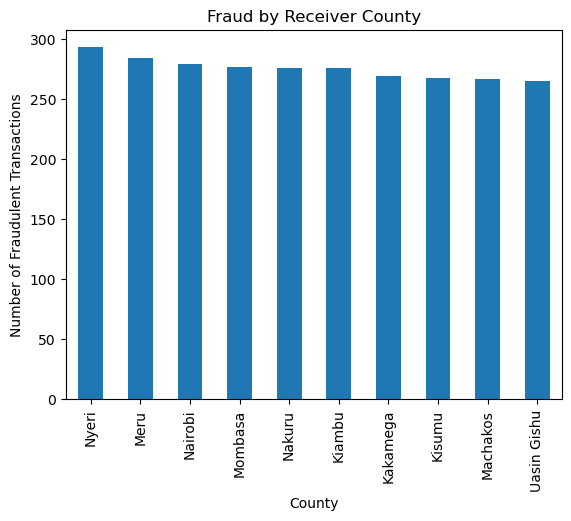

In [73]:
fradulent_df["ReceiverCounty"].value_counts().plot(kind="bar")

plt.title("Fraud by Receiver County")
plt.xlabel("County")
plt.ylabel("Number of Fraudulent Transactions")
plt.show()

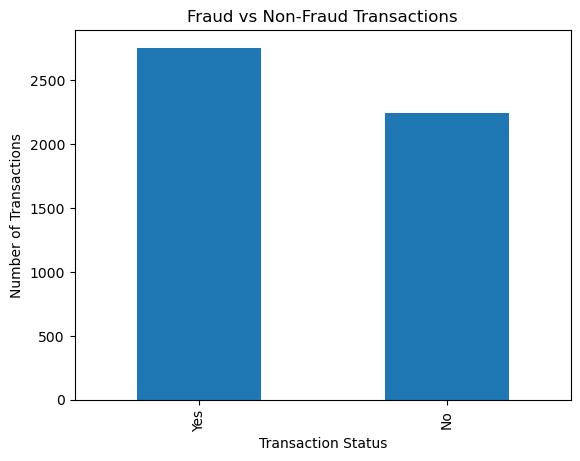

In [74]:
df["Fraudulent"].value_counts().plot(kind="bar")

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")
plt.show()

In [75]:
# Are transactions above KES 100,000 more risky?

In [76]:
df["HighAmount"] = df["Amount"] > 100000

In [77]:
high_amount_df = df[df["HighAmount"] == True]
low_amount_df = df[df["HighAmount"] == False]

In [78]:
high_fraud_rate = (high_amount_df["Fraudulent"] == "Yes").sum() / len(high_amount_df)

low_fraud_rate = (low_amount_df["Fraudulent"] == "Yes").sum() / len(low_amount_df)

print("High Amount Fraud Rate:", high_fraud_rate)
print("Low Amount Fraud Rate:", low_fraud_rate)

High Amount Fraud Rate: 0.5766716943187531
Low Amount Fraud Rate: 0.4500978473581213


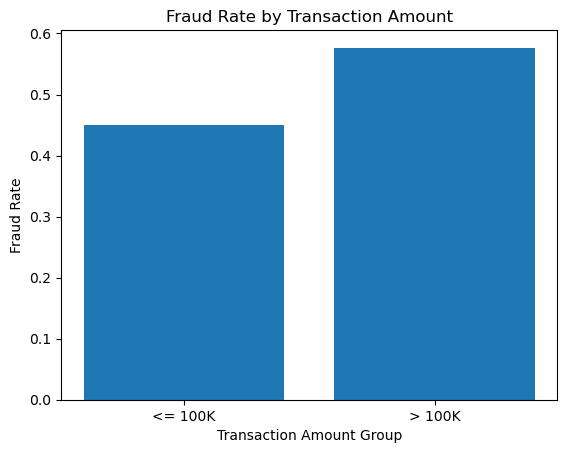

In [79]:
fraud_rates = [low_fraud_rate, high_fraud_rate]
labels = ["<= 100K", "> 100K"]

plt.bar(labels, fraud_rates)

plt.title("Fraud Rate by Transaction Amount")
plt.xlabel("Transaction Amount Group")
plt.ylabel("Fraud Rate")
plt.show()

In [80]:
# Transactions above KES 100,000 exhibit a higher fraud rate (57.7%) compared to lower-value transactions (45.0%)

In [81]:
# 6. ENCODE CATEGORICAL VARIABLE

In [82]:
categorical_cols = df.select_dtypes(include = ["object","bool"])
categorical_cols

,TransactionID,SenderCounty,ReceiverCounty,TransactionType,DeviceChangedRecently,NewLocationLogin,IsWeekend,Fraudulent,HighAmount
0,TXN000001,Mombasa,Nyeri,Withdraw,No,Yes,Yes,Yes,True
1,TXN000002,Nyeri,Nakuru,Withdraw,Yes,Yes,Yes,Yes,False
2,TXN000003,Machakos,Kiambu,Paybill,No,Yes,No,No,True
3,TXN000004,Machakos,Meru,Send Money,Yes,No,No,No,True
4,TXN000005,Meru,Machakos,Paybill,Yes,No,No,No,True
...,...,...,...,...,...,...,...,...,...
4995,TXN004996,Kiambu,Kiambu,Till,Yes,No,No,Yes,True
4996,TXN004997,Mombasa,Uasin Gishu,Till,Yes,No,No,Yes,True
4997,TXN004998,Meru,Mombasa,Send Money,Yes,No,Yes,No,False
4998,TXN004999,Nyeri,Kiambu,Send Money,No,Yes,No,Yes,True


In [83]:
le = LabelEncoder()

In [84]:
encoders = {}

categorical_cols = [
    "SenderCounty",
    "ReceiverCounty",
    "TransactionType",
    "DeviceChangedRecently",
    "NewLocationLogin",
    "IsWeekend",
    "Fraudulent"
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [85]:
df.head()

,TransactionID,Amount,SenderCounty,ReceiverCounty,TimeOfDay,TransactionType,AccountAgeMonths,TransactionsLast24Hours,DeviceChangedRecently,NewLocationLogin,FailedPinAttempts,IsWeekend,Fraudulent,HighAmount
0,TXN000001,335293,5,8,2,3,15,1,0,1,3,1,1,True
1,TXN000002,16713,8,7,22,3,4,3,1,1,8,1,1,False
2,TXN000003,115624,3,1,4,0,58,19,0,1,2,0,0,True
3,TXN000004,400340,3,4,8,1,44,4,1,0,1,0,0,True
4,TXN000005,382639,4,3,18,0,59,18,1,0,1,0,0,True


In [86]:
# FEATURE SELECTION

In [87]:
X = df.drop(["Fraudulent", "TransactionID", "HighAmount"], axis=1)

In [88]:
y = df["Fraudulent"]

In [89]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [90]:
# FITTING THE MODEL

In [91]:
model = RandomForestClassifier(random_state=43)
model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [92]:
y_pred = model.predict(x_test)

In [93]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison

,Actual,Predicted
1501,0,0
2586,1,1
2653,0,0
1055,1,1
705,0,0
...,...,...
4711,0,0
2313,1,1
3214,0,0
2732,1,1


In [94]:
# MODEL EVALUATION

In [95]:
accuracy_score(y_test, y_pred)

0.996

In [96]:
# CONFUSION MATRIX

In [97]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[467   0]
 [  4 529]]


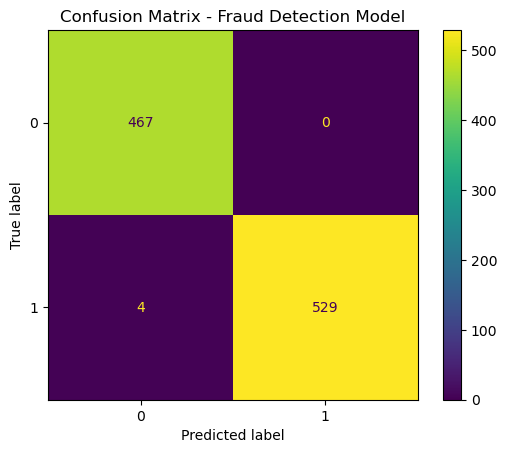

In [98]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix - Fraud Detection Model")
plt.show()

In [99]:
 # CLASSIFICATION REPORT

In [100]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       467
           1       1.00      0.99      1.00       533

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [101]:
# FEATURE IMPORTANCE

In [102]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
7,DeviceChangedRecently,0.285610
9,FailedPinAttempts,0.279973
8,NewLocationLogin,0.278632
0,Amount,0.047557
6,TransactionsLast24Hours,0.033863
5,AccountAgeMonths,0.028767
3,TimeOfDay,0.014831
1,SenderCounty,0.011339
2,ReceiverCounty,0.010629
4,TransactionType,0.005701


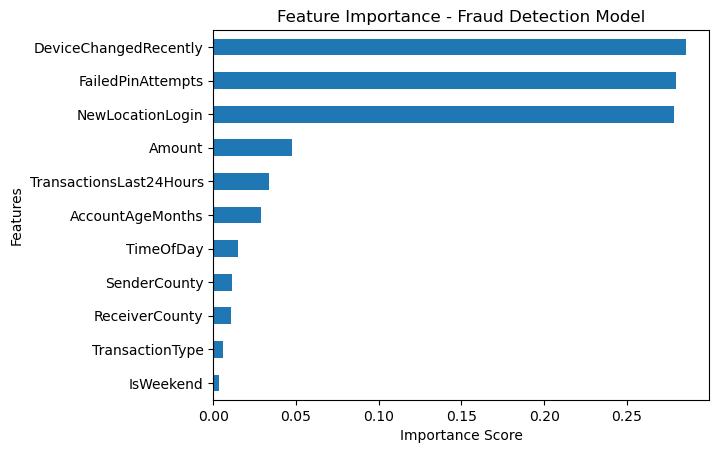

In [103]:
importance.sort_values(by="Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)

plt.title("Feature Importance - Fraud Detection Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [104]:
# The strongest indicators of fraud are Device Change, Failed PIN Attempts, and New Location Login.

In [107]:
for col in encoders:
    print("\nColumn:", col)

    print(list(zip(
        encoders[col].classes_,
        encoders[col].transform(encoders[col].classes_)
    )))


Column: SenderCounty
[('Kakamega', np.int64(0)), ('Kiambu', np.int64(1)), ('Kisumu', np.int64(2)), ('Machakos', np.int64(3)), ('Meru', np.int64(4)), ('Mombasa', np.int64(5)), ('Nairobi', np.int64(6)), ('Nakuru', np.int64(7)), ('Nyeri', np.int64(8)), ('Uasin Gishu', np.int64(9))]

Column: ReceiverCounty
[('Kakamega', np.int64(0)), ('Kiambu', np.int64(1)), ('Kisumu', np.int64(2)), ('Machakos', np.int64(3)), ('Meru', np.int64(4)), ('Mombasa', np.int64(5)), ('Nairobi', np.int64(6)), ('Nakuru', np.int64(7)), ('Nyeri', np.int64(8)), ('Uasin Gishu', np.int64(9))]

Column: TransactionType
[('Paybill', np.int64(0)), ('Send Money', np.int64(1)), ('Till', np.int64(2)), ('Withdraw', np.int64(3))]

Column: DeviceChangedRecently
[('No', np.int64(0)), ('Yes', np.int64(1))]

Column: NewLocationLogin
[('No', np.int64(0)), ('Yes', np.int64(1))]

Column: IsWeekend
[('No', np.int64(0)), ('Yes', np.int64(1))]

Column: Fraudulent
[('No', np.int64(0)), ('Yes', np.int64(1))]


In [112]:
transaction = model.predict([[250000, 6, 2, 23, 1, 1, 15, 1, 1, 5, 1]])

C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [113]:
if transaction == 0:
    print("not fraud")
else:
    print("fraud")

fraud
